<a href="https://colab.research.google.com/github/jcdumlao14/ESS11e04_1_DataAnalysis/blob/main/Country_Level_Analysis_Stressor_Means_(95_CI)_and_Odds_Ratios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARIES**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import zipfile
from sklearn.metrics import roc_auc_score, brier_score_loss
import warnings
import os

warnings.filterwarnings("ignore")


# **LOAD DATA**

In [ ]:
# LOAD DATA

zip_path = '/content/ESS11e04_1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ESS11e04_1.csv') as f:
        df = pd.read_csv(f, low_memory=False)

# Filter working adults 18-65
df = df[(df['pdwrk'] == 1) & (df['agea'] >= 18) & (df['agea'] <= 65)].copy()

missing_codes = [7, 8, 9, 66, 77, 88, 99, 666, 777, 888, 999]


# **COMPLETE COUNTRY & REGION MAPPING (30 COUNTRIES)**

In [ ]:
# REGION MAPPING
region_map = {
    'NO': 'North', 'SE': 'North', 'FI': 'North', 'IS': 'North', 'GB': 'North', 'IE': 'North',
    'FR': 'West', 'BE': 'West', 'NL': 'West', 'DE': 'West', 'AT': 'West', 'CH': 'West',
    'ES': 'South', 'PT': 'South', 'IT': 'South', 'GR': 'South', 'CY': 'South',
    'PL': 'East', 'SK': 'East', 'HU': 'East', 'BG': 'East', 'SI': 'East', 'HR': 'East',
    'EE': 'East', 'LT': 'East', 'LV': 'East', 'ME': 'East', 'RS': 'East', 'UA': 'East',
    'IL': 'Middle East'
}

def get_region(code):
    if pd.isna(code): return 'Unknown'
    return region_map.get(str(code).upper(), 'Unknown')

df['region'] = df['cntry'].apply(get_region)

# COUNTRY NAME MAPPING
country_names = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CH': 'Switzerland', 'CY': 'Cyprus',
    'DE': 'Germany', 'EE': 'Estonia', 'ES': 'Spain', 'FI': 'Finland', 'FR': 'France',
    'GB': 'United Kingdom', 'GR': 'Greece', 'HR': 'Croatia', 'HU': 'Hungary', 'IE': 'Ireland',
    'IL': 'Israel', 'IS': 'Iceland', 'IT': 'Italy', 'LT': 'Lithuania', 'LV': 'Latvia',
    'ME': 'Montenegro', 'NL': 'Netherlands', 'NO': 'Norway', 'PL': 'Poland', 'PT': 'Portugal',
    'RS': 'Serbia', 'SE': 'Sweden', 'SI': 'Slovenia', 'SK': 'Slovakia', 'UA': 'Ukraine'
}

df['country_name'] = df['cntry'].map(country_names)
df['Country'] = df['country_name'].fillna('Unknown')


# **OUTCOME & CONTROLS/ DEMANDS & RESOURCES**

In [ ]:
# OUTCOME & CONTROLS
df['CVD'] = pd.to_numeric(df['hltprhc'], errors='coerce').replace(missing_codes, np.nan)
# Convert CVD to binary (1 = Yes, 0 = No)
df['CVD_binary'] = df['CVD'].apply(lambda x: 1 if x == 1 else (0 if x == 2 else np.nan))

df['age'] = pd.to_numeric(df['agea'], errors='coerce')
df['gender'] = df['gndr'].map({1:'Male', 2:'Female'})
df['edu'] = pd.to_numeric(df['eduyrs'], errors='coerce').replace(missing_codes, np.nan)

# DEMANDS & RESOURCES
physical_vars = ['jbexpvi','jbexpti','jbexpml','jbexpmc']
existing_physical_vars = [v for v in physical_vars if v in df.columns]
df['dem_physical'] = df[existing_physical_vars].apply(pd.to_numeric, errors='coerce').replace(missing_codes,0).sum(axis=1) if existing_physical_vars else np.nan

df['dem_workload'] = pd.to_numeric(df['wkhtot'], errors='coerce').replace(missing_codes,np.nan)
df['dem_financial'] = pd.to_numeric(df['hincfel'], errors='coerce').replace(missing_codes,np.nan)

resource_vars = ['wkdcorga','wkdcorgb','wkdcorgc']
existing_resource_vars = [v for v in resource_vars if v in df.columns]
df['res_control'] = df[existing_resource_vars].apply(pd.to_numeric, errors='coerce').replace(missing_codes,np.nan).mean(axis=1) if existing_resource_vars else np.nan


# **COUNTRY SUMMARY FUNCTION**

In [ ]:
# COUNTRY SUMMARY FUNCTION

def get_stats(group):
    clean = group.dropna()
    n = len(clean)
    if n==0:
        return pd.Series({'N':0,'Mean':np.nan,'Std':np.nan,'SE':np.nan,'CI (95%)':"N/A"})
    mean = clean.mean()
    std = clean.std()
    se = std/np.sqrt(n)
    ci_low = mean - 1.96*se
    ci_high = mean + 1.96*se
    return pd.Series({'N':n,'Mean':round(mean,3),'Std':round(std,3),'SE':round(se,3),'CI (95%)':f"[{ci_low:.3f},{ci_high:.3f}]"})


# ANALYSIS + PLOT

def run_analysis(var_name, save_dir='plots'):
    print(f"\n=== {var_name.upper()} BY COUNTRY ===")

    os.makedirs(save_dir, exist_ok=True)

    # Drop missing countries for summary
    df_var = df[[var_name,'Country']].dropna(subset=['Country'])

    # Summary stats
    stats_output = df_var.groupby('Country')[var_name].apply(get_stats).unstack()

    # Prepare logistic regression per country
    model_cols = ['CVD','age','gender','edu',var_name,'Country']
    df_model = df[model_cols].copy()

    # Only drop NaN in predictor/outcome columns, keep Country
    df_model = df_model.dropna(subset=['CVD','age','gender','edu',var_name,'Country'])
    df_model['CVD'] = df_model['CVD'].apply(lambda x:1 if x==1 else 0)

    results=[]
    for country,d in df_model.groupby('Country'):
        if len(d) < 30:
            continue
        try:
            model = smf.logit(f"CVD~age+gender+edu+{var_name}", data=d).fit(disp=0)
            or_val = np.exp(model.params[var_name])
            p_val = model.pvalues[var_name]
            y_true = d['CVD']
            y_pred = model.predict(d)
            auc = roc_auc_score(y_true, y_pred)
            brier = brier_score_loss(y_true, y_pred)
            results.append({'Country':country,'OR':round(or_val,4),'p_value':round(p_val,4),'auc':round(auc,4),'brier_score':round(brier,4)})
        except:
            continue

    metrics = pd.DataFrame(results).set_index('Country')
    final = stats_output.join(metrics, how='outer')

    # Display table
    display(final[['N','Mean','Std','SE','CI (95%)','OR','p_value','auc','brier_score']])

    # ----- PLOT -----
    plt.figure(figsize=(12,6))
    x = np.arange(len(final))
    y = final['Mean'].values
    yerr = (final['SE']*1.96).values if 'SE' in final.columns else None

    plt.bar(x, y, yerr=yerr, capsize=5, color=plt.cm.viridis(x/len(x)))
    plt.xticks(x, final.index, rotation=90)
    plt.ylabel("Mean")
    plt.title(f"{var_name} Mean by Country with 95% CI")

    if 'OR' in final.columns:
        ax2 = plt.twinx()
        ax2.plot(x, final['OR'].values, color='red', marker='o', label='OR')
        ax2.set_ylabel("OR", color='red')
        ax2.tick_params(axis='y', colors='red')
        ax2.legend(loc='upper right')

    plt.tight_layout()

    # Save plot
    save_path = os.path.join(save_dir, f"{var_name}_by_country.png")
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved to: {save_path}")

    plt.show()


# **MULTILEVEL MODEL (COUNTRY EFFECTS)**

In [ ]:
# MULTILEVEL MODEL (COUNTRY EFFECTS)

def run_multilevel_model():
    print("\n=== MULTILEVEL MODEL (COUNTRY EFFECTS) ===")

    # Prepare data
    cols = ['CVD','age','gender','edu','dem_physical','dem_workload','dem_financial','res_control','Country']
    df_model = df[cols].dropna()

    df_model['CVD'] = df_model['CVD'].apply(lambda x:1 if x==1 else 0)
    df_model['gender'] = df_model['gender'].astype('category')

    formula = "CVD ~ age + gender + edu + dem_physical + dem_workload + dem_financial + res_control"

    model = mixedlm(formula, data=df_model, groups=df_model["Country"])
    result = model.fit(reml=True)

    print(result.summary())


# **RUN ALL ANALYSES**


=== DEM_PHYSICAL BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,1117,0.799,1.109,0.033,"[0.734,0.865]",1.3173,0.0380,0.6669,0.0404
Belgium,788,1.029,1.103,0.039,"[0.952,1.106]",1.0996,0.5276,0.6440,0.0511
Bulgaria,1083,0.604,0.88,0.027,"[0.551,0.656]",1.1716,0.3275,0.7079,0.0481
Croatia,690,0.923,1.073,0.041,"[0.843,1.003]",1.2108,0.2818,0.6797,0.0386
Cyprus,324,0.62,0.967,0.054,"[0.515,0.726]",1.0207,0.9445,0.7399,0.0306
Estonia,776,1.182,1.143,0.041,"[1.101,1.262]",1.3087,0.0469,0.6653,0.0585
Finland,788,1.549,1.274,0.045,"[1.461,1.638]",1.2653,0.0737,0.6943,0.0511
France,918,1.179,1.178,0.039,"[1.102,1.255]",1.0229,0.8780,0.6251,0.0411
Germany,1370,1.103,1.194,0.032,"[1.040,1.166]",1.2539,0.0044,0.6031,0.0809


Plot saved to: plots/dem_physical_by_country.png


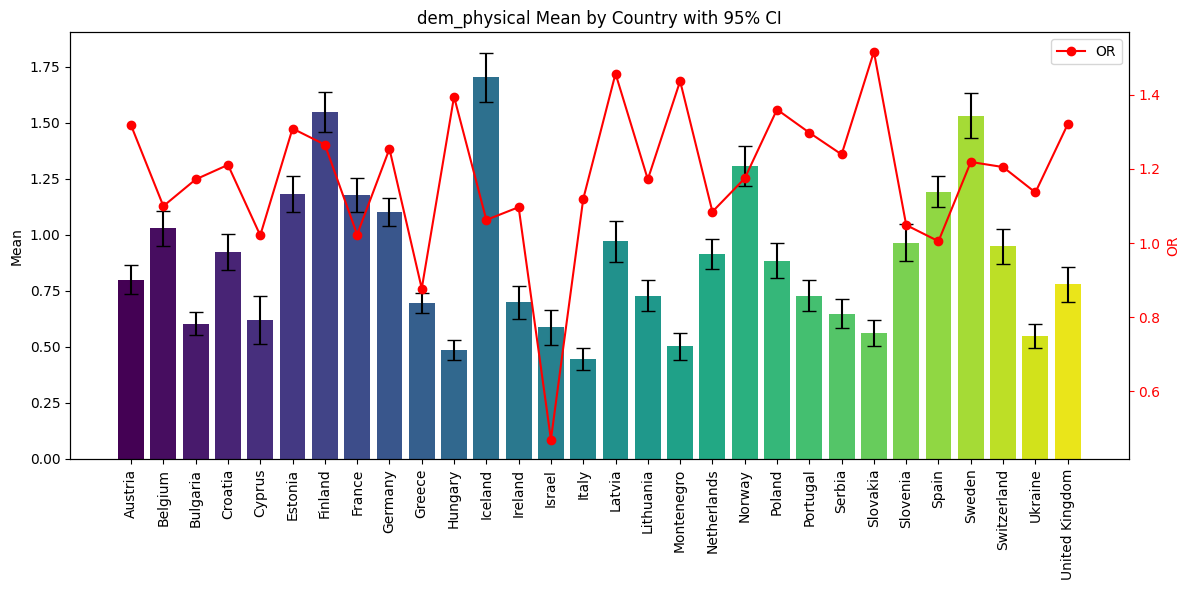


=== DEM_WORKLOAD BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,1052,37.812,9.016,0.278,"[37.267,38.357]",0.9823,0.2846,0.6590,0.0407
Belgium,771,40.267,15.982,0.576,"[39.139,41.395]",1.0170,0.0475,0.6518,0.0506
Bulgaria,992,44.418,11.15,0.354,"[43.724,45.112]",1.0146,0.1319,0.7172,0.0496
Croatia,670,42.387,10.973,0.424,"[41.556,43.217]",1.0051,0.7572,0.6834,0.0398
Cyprus,316,41.212,17.313,0.974,"[39.303,43.121]",0.9820,0.3540,0.7787,0.0312
Estonia,737,41.281,16.532,0.609,"[40.087,42.474]",1.0093,0.2191,0.6448,0.0593
Finland,775,36.987,12.262,0.44,"[36.124,37.850]",0.9997,0.9818,0.6716,0.0497
France,896,39.026,12.36,0.413,"[38.216,39.835]",1.0096,0.3309,0.6245,0.0418
Germany,1348,37.226,11.699,0.319,"[36.601,37.850]",1.0044,0.6273,0.5790,0.0820


Plot saved to: plots/dem_workload_by_country.png


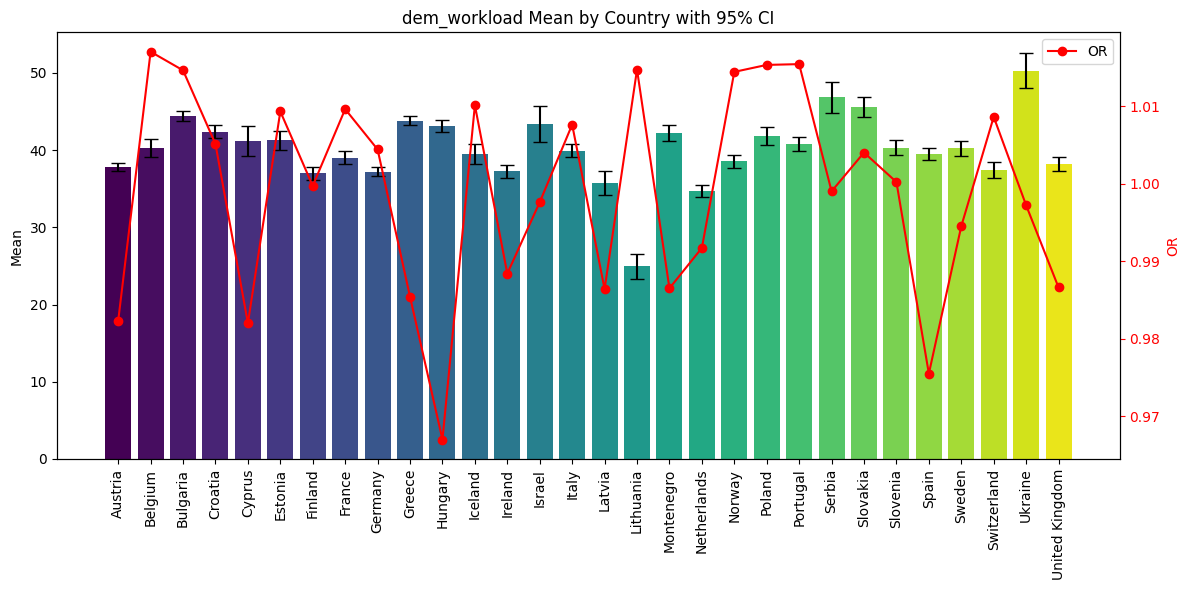


=== DEM_FINANCIAL BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,1110,1.77,0.654,0.02,"[1.732,1.809]",1.8038,0.0072,0.6854,0.0405
Belgium,787,1.595,0.708,0.025,"[1.545,1.644]",0.8810,0.6147,0.6378,0.0511
Bulgaria,1079,2.277,0.736,0.022,"[2.233,2.321]",0.6421,0.0495,0.7224,0.0483
Croatia,684,1.735,0.675,0.026,"[1.685,1.786]",0.6556,0.2126,0.6879,0.0388
Cyprus,319,2.003,0.845,0.047,"[1.910,2.096]",2.9221,0.0105,0.8556,0.0304
Estonia,776,1.852,0.649,0.023,"[1.806,1.897]",1.3780,0.1796,0.6599,0.0588
Finland,787,1.71,0.626,0.022,"[1.667,1.754]",1.8477,0.0118,0.7021,0.0510
France,916,1.706,0.695,0.023,"[1.661,1.751]",1.1698,0.5137,0.6310,0.0412
Germany,1367,1.541,0.635,0.017,"[1.508,1.575]",1.3182,0.0589,0.5926,0.0814


Plot saved to: plots/dem_financial_by_country.png


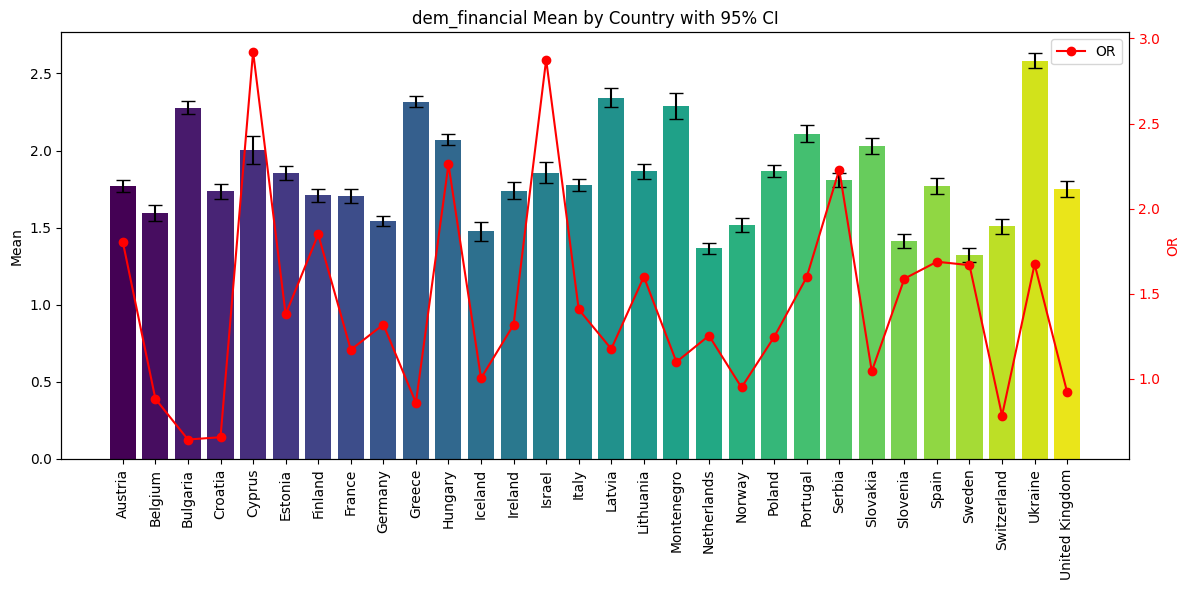


=== RES_CONTROL BY COUNTRY ===


,N,Mean,Std,SE,CI (95%),OR,p_value,auc,brier_score
Country,,,,,,,,,
Austria,720,5.971,3.225,0.12,"[5.735,6.206]",0.8888,0.0452,0.6707,0.0471
Belgium,349,7.069,3.681,0.197,"[6.683,7.455]",1.0668,0.4219,0.7115,0.0517
Bulgaria,849,4.975,3.806,0.131,"[4.719,5.231]",1.0556,0.2033,0.7329,0.0522
Croatia,477,4.7,3.849,0.176,"[4.355,5.046]",0.9502,0.3985,0.7529,0.0413
Cyprus,216,5.977,3.988,0.271,"[5.445,6.509]",1.2280,0.1266,0.8636,0.0305
Estonia,418,7.211,3.469,0.17,"[6.878,7.543]",0.9332,0.2266,0.6994,0.0628
Finland,304,7.312,3.384,0.194,"[6.932,7.693]",0.9825,0.8151,0.6752,0.0619
France,527,6.56,3.864,0.168,"[6.230,6.890]",1.0025,0.9647,0.6564,0.0507
Germany,706,7.293,3.433,0.129,"[7.040,7.546]",0.9579,0.2765,0.5520,0.0852


Plot saved to: plots/res_control_by_country.png


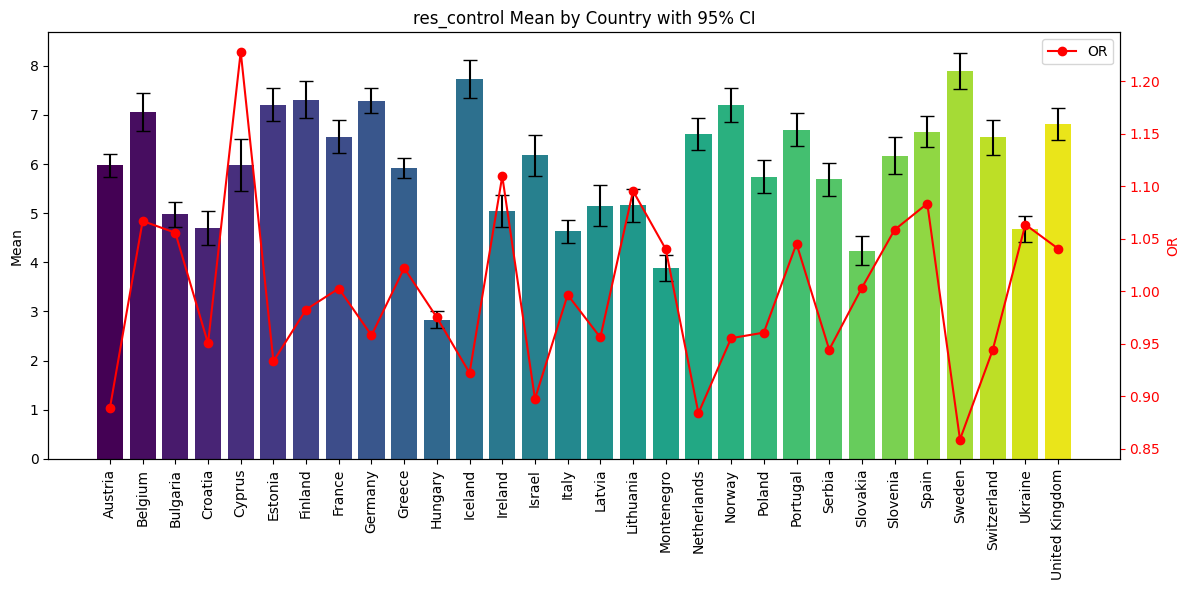


=== MULTILEVEL MODEL (COUNTRY EFFECTS) ===
          Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  CVD   
No. Observations:    13947    Method:              REML  
No. Groups:          30       Scale:               0.0475
Min. group size:     198      Log-Likelihood:      inf   
Max. group size:     1050     Converged:           Yes   
Mean group size:     464.9                               
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      -0.000                                    
gender[T.Male] -0.003    0.004 -0.870 0.384 -0.011  0.004
age             0.002    0.000 12.959 0.000  0.002  0.002
edu            -0.000    0.001 -0.011 0.991 -0.001  0.001
dem_physical    0.009    0.002  4.575 0.000  0.005  0.012
dem_workload    0.000    0.000  0.609 0.543 -0.000  0.000
dem_financial   0.012    0.003  4.354 

In [ ]:
# RUN ALL ANALYSES

variables = ['dem_physical','dem_workload','dem_financial','res_control']

for var in variables:
    run_analysis(var)

# Multilevel model
run_multilevel_model()

# **Overview**
The analysis utilized data from the European Social Survey (ESS11), focusing on working adults. It combined country-level descriptive statistics with Odds Ratios (OR) and a Multilevel Model (MixedLM) to identify which stressors are universal drivers of cardiovascular risk versus those that are country-specific.


**1. Financial Stress (dem_financial)**

Financial strain is the most consistent and potent predictor of heart health risk across Europe.
  - **Landscape:** The highest levels of financial strain are reported in Eastern and Southern Europe, specifically **Ukraine** (Mean: 2.58), **Latvia** (2.34), **Greece** (2.31), and **Bulgaria** (2.27).
  - **CVD Risk:** This stressor shows the strongest associations with CVD risk. In **Cyprus** (OR: 2.92), **Israel** (OR: 2.87), **Hungary** (OR: 2.25), and **Serbia** (OR: 2.22), the risk of CVD increases dramatically with each level of financial stress.
  - **Universal Trend:** Even in countries with lower average stress, such as **Austria** (OR: 1.80) and **Finland** (OR: 1.84), the connection remains statistically significant and high.

**2. Physical Job Demands (dem_physical)**

Physical strain is a major universal predictor, though reported exposure levels vary significantly by region.
  - **Landscape:** Nordic countries report the highest physical demands, led by **Iceland** (Mean: 1.70), **Finland** (1.55), and **Sweden** (1.53). The lowest levels are found in **Italy** (0.44) and **Hungary** (0.48).
  - **CVD Risk:** Higher physical demands significantly increase heart risk in several countries, most notably **Slovakia** (OR: 1.51), **Latvia** (OR: 1.45), **Poland** (OR: 1.36), and **Austria** (OR: 1.31).
  - **Universal Trend:** The Multilevel Model confirms physical demands as a highly significant universal driver (p < 0.001) across the entire European sample.

**3. Job Control (res_control)**

Employee autonomy serves as a protective factor in specific Western European contexts but is not a universal predictor.
  - **Landscape:** Job control is highest in **Sweden** (Mean: 7.89), **Iceland** (7.73), and **Germany** (7.29). It is lowest in **Hungary** (2.83) and **Montenegro** (3.88).
  - **CVD Risk:** In the **Netherlands** (OR: 0.88) and **Austria** (OR: 0.88), higher job control is significantly associated with lower CVD risk (p < 0.05).
  - **Universal Trend:** When analyzing all countries together, Job Control did not reach statistical significance as a universal predictor (p=0.494).

**4. Workload (dem_workload)**

Total workload, measured in hours/intensity, showed the weakest connection to cardiovascular health.
  - **Landscape:** The highest workloads are reported in **Ukraine** (Mean: 50.31), **Serbia** (46.84), and **Slovakia** (45.60). The lowest are in **Lithuania** (24.99) and the **Netherlands** (34.72).
  - **CVD Risk:** While statistically significant in **Belgium** and **Lithuania**, the Odds Ratios are very close to 1.0 (OR: 1.01), indicating a very small effect size.
  - **Universal Trend:** The Multilevel Model showed that workload is not a significant universal predictor of CVD (p=0.543) when other factors are controlled.

# **Multilevel Model Results**

The Mixed Linear Model, which controls for age, gender, and education across all 30 countries, reveals the following:
1. **Primary Driver:** Age is the most significant factor in CVD risk (p < 0.001).
2. **Universal Workplace Stressors:** Only **Physical Job Demands** and **Financial Stress** are statistically significant universal predictors of CVD (p < 0.001).
3. **Non-Significant Factors:** Education level, gender, total workload, and job control do not act as universal predictors across the European sample when physical and financial stressors are included in the model.

# **Conclusion**
Among European workers, **financial instability** and **physical strain** are the critical occupational determinants of cardiovascular disease. While financial stress is the primary burden in Southern and Eastern Europe, physical demands are notably high in the North. Traditional **"work-life"** metrics like workload and job autonomy, while important for general well-being, are less impactful on direct heart health than economic and physical stressors.